In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Project root (launch Jupyter from the repository root)
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train_FD001.txt"



In [2]:
columns = (
    ["engine_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Engine lifetime statistics:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


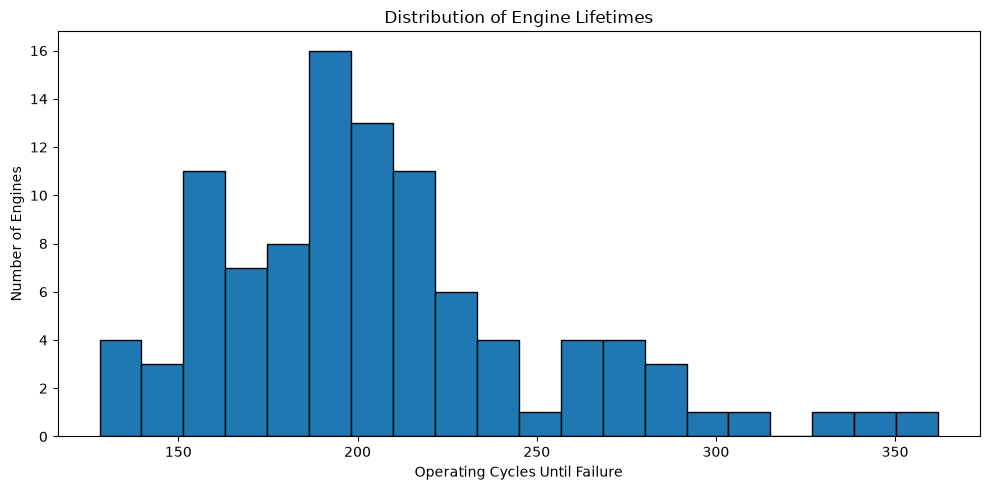

In [3]:
# Maximum operating cycle for each engine
engine_lifetimes = df.groupby("engine_id")["cycle"].max()

print("Engine lifetime statistics:")
print(engine_lifetimes.describe())

# Plot engine lifetime distribution
plt.figure(figsize=(10, 5))

plt.hist(
    engine_lifetimes,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Operating Cycles Until Failure")
plt.ylabel("Number of Engines")

plt.tight_layout()
plt.show()

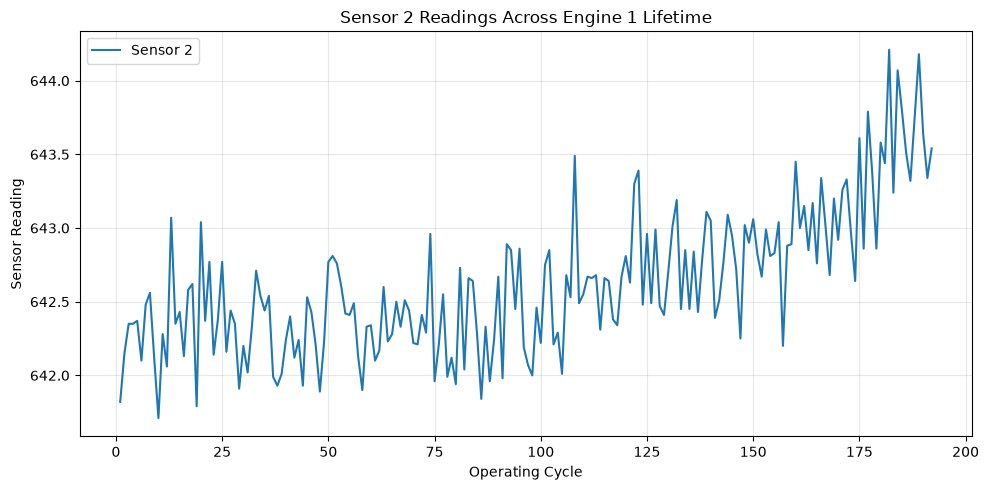

In [4]:
# Select Engine 1
engine_1 = df[df["engine_id"] == 1]

plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"],
    label="Sensor 2"
)

plt.title("Sensor 2 Readings Across Engine 1 Lifetime")
plt.xlabel("Operating Cycle")
plt.ylabel("Sensor Reading")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## EDA Findings: Engine Lifetime and Sensor Trends

### 1. Engine Lifetime Distribution

The FD001 training dataset contains 100 engines with different operating lifetimes.

* Mean lifetime: 206.31 cycles
* Median lifetime: 199 cycles
* Minimum lifetime: 128 cycles
* Maximum lifetime: 362 cycles
* Standard deviation: 46.34 cycles

**Observation:** Engine lifetimes vary considerably. Most lifetimes are concentrated around the middle of the distribution, with a few engines operating substantially longer.

**Implication:** A fixed engine lifetime is insufficient for estimating remaining useful life. We need to investigate whether sensor measurements and operating history provide useful predictive information.

### 2. Sensor 2 Trend Analysis

Sensor 2 readings for Engine 1 show an overall increasing trend, particularly during later operating cycles.

**Observation:** The readings contain fluctuations but tend to increase as the engine approaches its final cycle.

**Implication:** Sensor 2 may contain useful degradation-related information. Further analysis across multiple engines is required before determining its predictive value.


In [5]:
# Select all sensor columns
sensor_columns = [
    f"sensor_{i}" for i in range(1, 22)
]

# Count the number of unique values in each sensor
sensor_unique_values = df[sensor_columns].nunique()

print("Unique values per sensor:")
print(sensor_unique_values)

# Identify sensors with exactly one unique value
constant_sensors = sensor_unique_values[
    sensor_unique_values == 1
].index.tolist()

print("\nConstant sensors:")
print(constant_sensors)

Unique values per sensor:
sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
dtype: int64

Constant sensors:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


### 3. Constant Sensor Analysis

The FD001 training dataset contains 21 sensor measurements.

The uniqueness analysis identified six constant sensors:

`sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`.

These sensors have only one unique value across the training dataset and therefore provide no variation for predicting RUL.

**Preprocessing decision:** Exclude the six constant sensors from the initial model's feature set.

The remaining 15 sensors will be investigated further to determine whether their readings contain useful degradation-related information.

Sensors with low variability will not be removed solely on the basis of their number of unique values.


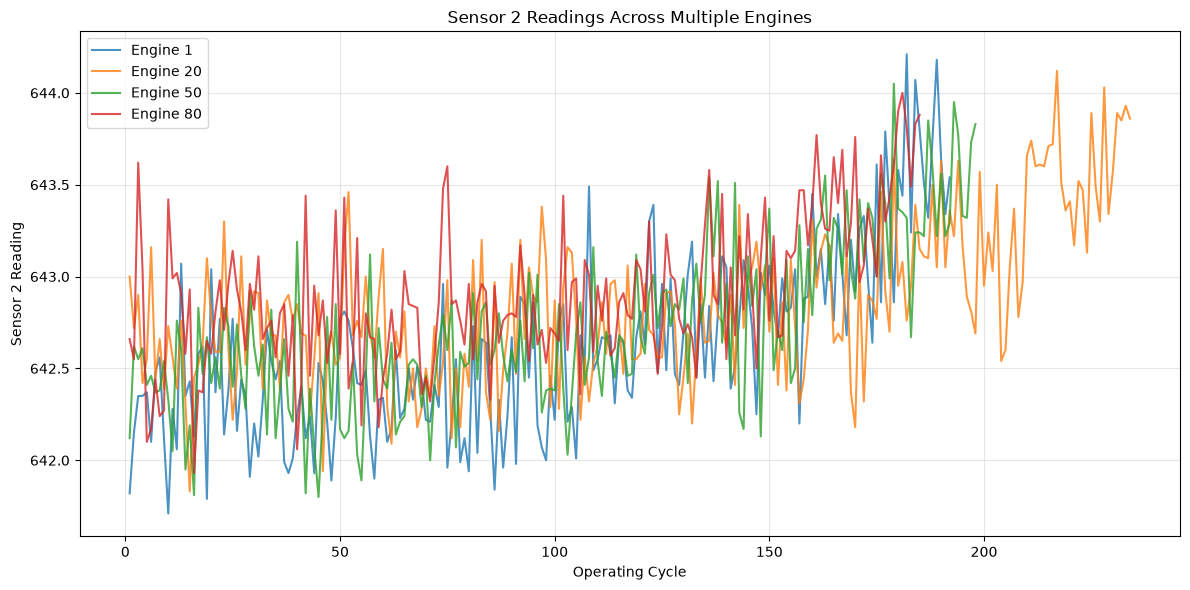

In [6]:
# Select four engines for comparison
selected_engines = [1, 20, 50, 80]

plt.figure(figsize=(12, 6))

# Plot Sensor 2 readings for each engine
for engine_id in selected_engines:

    engine_data = df[df["engine_id"] == engine_id]

    plt.plot(
        engine_data["cycle"],
        engine_data["sensor_2"],
        label=f"Engine {engine_id}",
        alpha=0.8
    )

plt.title("Sensor 2 Readings Across Multiple Engines")
plt.xlabel("Operating Cycle")
plt.ylabel("Sensor 2 Reading")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 4. Sensor Trend Comparison Across Multiple Engines

Sensor 2 was analyzed across Engines 1, 20, 50, and 80.

**Observations:**

* All four engines exhibit a generally increasing trend in Sensor 2 readings, particularly during later operating cycles.
* Sensor measurements contain noticeable fluctuations.
* Engines have different operating lifetimes, as indicated by the different endpoints of their trajectories.
* Sensor readings vary between engines, even at similar operating cycles.

**Interpretation:**

Sensor 2 may contain degradation-related information, but its readings alone may not be sufficient for accurate RUL prediction.

Further investigation of other sensors and evaluation on unseen engines are necessary to determine its predictive usefulness.

**Potential feature-engineering approach:** Explore historical sensor trends and rolling averages to reduce the influence of short-term fluctuations.


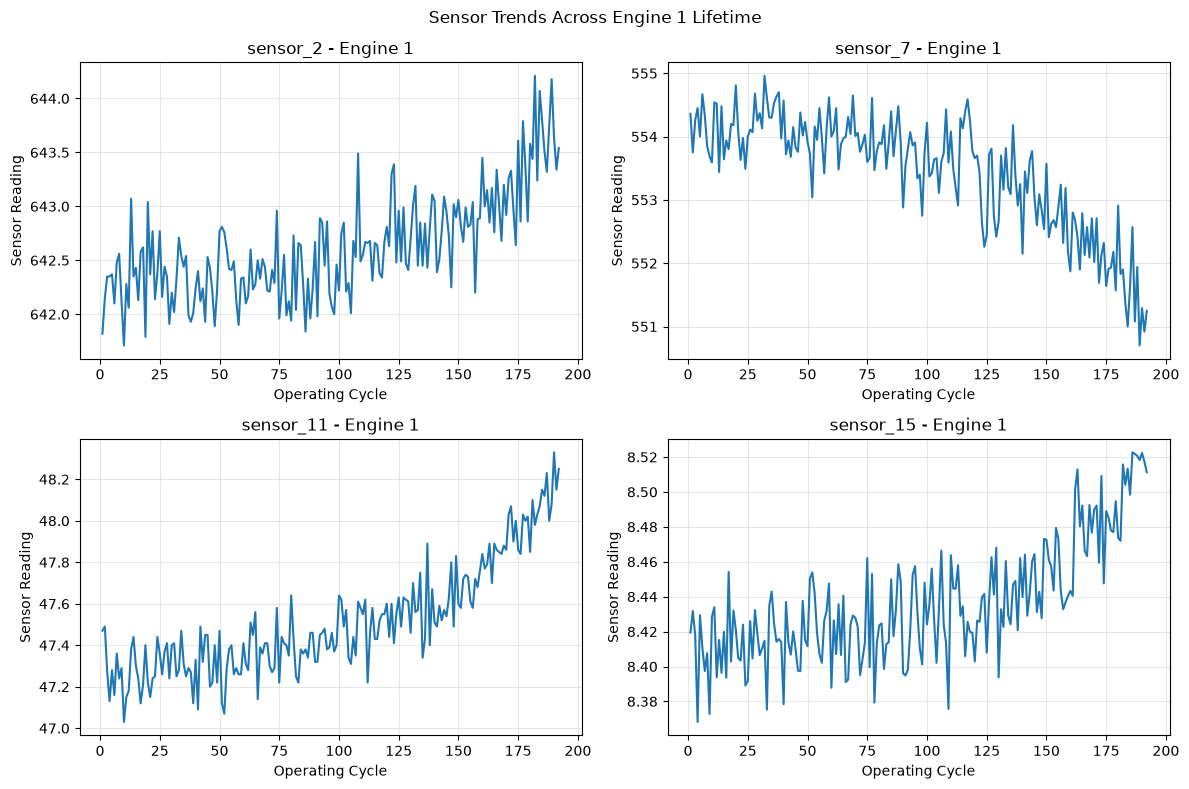

In [7]:
# Select Engine 1
engine_data = df[df["engine_id"] == 1]

# Select sensors to investigate
selected_sensors = [
    "sensor_2",
    "sensor_7",
    "sensor_11",
    "sensor_15"
]

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot each sensor
for ax, sensor in zip(axes.flatten(), selected_sensors):

    ax.plot(
        engine_data["cycle"],
        engine_data[sensor]
    )

    ax.set_title(f"{sensor} - Engine 1")
    ax.set_xlabel("Operating Cycle")
    ax.set_ylabel("Sensor Reading")
    ax.grid(alpha=0.3)

plt.suptitle("Sensor Trends Across Engine 1 Lifetime")

plt.tight_layout()
plt.show()

### 5. Analysis of Multiple Sensor Trends

Four sensor measurements were examined across the operating lifetime of Engine 1.

**Observations:**

| Sensor    | Observed trend       |
| --------- | -------------------- |
| Sensor 2  | Generally increasing |
| Sensor 7  | Generally decreasing |
| Sensor 11 | Generally increasing |
| Sensor 15 | Generally increasing |

The sensor readings contain fluctuations, but their overall trends become more noticeable during later operating cycles.

**Interpretation:**

Different sensors exhibit different patterns as the engine approaches its final operating cycle.

These patterns may contain useful information for remaining useful life prediction.

However, the observations are based on a single engine. Their predictive value must be evaluated across multiple engines and validated using unseen engine trajectories.

**Potential feature-engineering approach:** Investigate rolling averages and recent sensor trends to capture changes in engine condition.


In [8]:
# 1. Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# 2. Check whether each engine-cycle pair is unique
print(
    "Duplicate engine-cycle pairs:",
    df.duplicated(subset=["engine_id", "cycle"]).sum()
)

# 3. Check operational settings
setting_columns = ["setting_1", "setting_2", "setting_3"]

print("\nUnique values in operational settings:")
print(df[setting_columns].nunique())

# 4. Check data types
print("\nDataset data types:")
print(df.dtypes.value_counts())

# 5. Check whether cycle numbering is continuous
cycle_check = df.groupby("engine_id")["cycle"].apply(
    lambda cycles: (
        cycles.min() == 1
        and cycles.nunique() == cycles.max()
        and len(cycles) == cycles.max()
    )
)

print("\nEngines with valid cycle numbering:", cycle_check.sum())
print("Engines with invalid cycle numbering:", (~cycle_check).sum())

Duplicate rows: 0
Duplicate engine-cycle pairs: 0

Unique values in operational settings:
setting_1    158
setting_2     13
setting_3      1
dtype: int64

Dataset data types:
float64    22
int64       4
Name: count, dtype: int64

Engines with valid cycle numbering: 100
Engines with invalid cycle numbering: 0


### 6. Data Quality Assessment

The FD001 training dataset was checked for missing values, duplicates, operational-setting variability, and cycle-numbering consistency.

**Findings:**

* No missing values were detected.
* No duplicate rows or duplicate engine-cycle combinations were found.
* All 100 engines have valid cycle numbering, starting at cycle 1.
* All 26 original columns are numerical.
* `setting_3` is constant, while `setting_1` and `setting_2` vary.

**Preprocessing decisions:**

1. No missing-value imputation is currently required.
2. No duplicate removal is required.
3. The six constant sensors and `setting_3` are candidates for exclusion from the model.
4. Feature-selection and preprocessing decisions will be fitted using training data only to avoid data leakage.

The dataset is ready for the initial machine learning preparation stage.


## 7. Data Preparation and Train-Validation Split

In [9]:
from sklearn.model_selection import GroupShuffleSplit

# Step 1: Calculate RUL for training trajectories
df["rul"] = (
    df.groupby("engine_id")["cycle"].transform("max")
    - df["cycle"]
)

# Step 2: Initialize group-based splitting
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Step 3: Split by engine ID
train_idx, val_idx = next(
    splitter.split(
        df,
        groups=df["engine_id"]
    )
)

# Step 4: Create separate datasets
train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()

# Step 5: Verify results
print("Training engines:", train_df["engine_id"].nunique())
print("Validation engines:", val_df["engine_id"].nunique())

print("\nTraining rows:", len(train_df))
print("Validation rows:", len(val_df))

# Confirm there is no engine overlap
train_engines = set(train_df["engine_id"])
val_engines = set(val_df["engine_id"])

overlap = train_engines.intersection(val_engines)

print("\nOverlapping engines:", overlap)

assert len(overlap) == 0, "Data leakage detected!"

print("\nTrain-validation split successful!")

Training engines: 80
Validation engines: 20

Training rows: 16561
Validation rows: 4070

Overlapping engines: set()

Train-validation split successful!


## 8. Baseline Model Development

In [10]:
# Identify constant columns using TRAINING data only
candidate_features = [
    col for col in train_df.columns
    if col not in ["engine_id", "rul"]
]

constant_features = [
    col for col in candidate_features
    if train_df[col].nunique() == 1
]

# Remove constant features
feature_columns = [
    col for col in candidate_features
    if col not in constant_features
]

print("Constant features:", constant_features)
print("Selected features:", feature_columns)
print("Total features:", len(feature_columns))

Constant features: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Selected features: ['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Total features: 18


In [11]:
# Input features
X_train = train_df[feature_columns]
X_val = val_df[feature_columns]

# Target variable
y_train = train_df["rul"]
y_val = val_df["rul"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (16561, 18)
X_val: (4070, 18)
y_train: (16561,)
y_val: (4070,)


In [12]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize the baseline
dummy_model = DummyRegressor(strategy="mean")

# Train
dummy_model.fit(X_train, y_train)

# Predict on validation data
dummy_predictions = dummy_model.predict(X_val)

# Calculate evaluation metrics
dummy_mae = mean_absolute_error(y_val, dummy_predictions)

dummy_rmse = np.sqrt(
    mean_squared_error(y_val, dummy_predictions)
)

print("Dummy Regressor Results")
print("MAE:", round(dummy_mae, 2))
print("RMSE:", round(dummy_rmse, 2))

Dummy Regressor Results
MAE: 55.36
RMSE: 65.72


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Create the model pipeline
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0))
])

# Train on training engines
ridge_model.fit(X_train, y_train)

# Predict on unseen validation engines
ridge_predictions = ridge_model.predict(X_val)

# Calculate metrics
ridge_mae = mean_absolute_error(y_val, ridge_predictions)

ridge_rmse = np.sqrt(
    mean_squared_error(y_val, ridge_predictions)
)

print("Ridge Regression Results")
print("MAE:", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))

Ridge Regression Results
MAE: 25.16
RMSE: 31.66


In [14]:
# Compare baseline and Ridge results
results = pd.DataFrame({
    "Model": ["Dummy Regressor", "Ridge Regression"],
    "MAE": [dummy_mae, ridge_mae],
    "RMSE": [dummy_rmse, ridge_rmse]
})

print(results.round(2))

              Model    MAE   RMSE
0   Dummy Regressor  55.36  65.72
1  Ridge Regression  25.16  31.66


## 8.1 Baseline Model Results

Two regression models were trained using 80 engine trajectories and evaluated on 20 unseen engine trajectories.

**Feature selection:** Seven constant features were excluded based on training data, leaving 18 input features.

| Model            | MAE (cycles) | RMSE (cycles) |
| ---------------- | -----------: | ------------: |
| Dummy Regressor  |        55.36 |         65.72 |
| Ridge Regression |        25.16 |         31.66 |

### Observations

* Ridge Regression achieved substantially lower validation errors than the Dummy Regressor.
* The results suggest that the selected engine measurements and operating cycle contain information useful for RUL prediction.
* Ridge Regression provides an initial benchmark for evaluating more complex models.

### Limitations

These metrics are calculated across all observed cycles of the validation engines. Further evaluation using truncated engine trajectories is needed to approximate the prediction setting used in the NASA test dataset.

We will also investigate prediction errors and check for physically invalid negative RUL predictions.


## 9. Prediction Error Analysis

In [15]:
# Create a comparison of actual and predicted values

prediction_analysis = pd.DataFrame({
    "engine_id": val_df["engine_id"].values,
    "cycle": val_df["cycle"].values,
    "actual_rul": y_val.values,
    "predicted_rul": ridge_predictions
})

# Calculate individual prediction errors
prediction_analysis["error"] = (
    prediction_analysis["actual_rul"]
    - prediction_analysis["predicted_rul"]
)

prediction_analysis["absolute_error"] = (
    prediction_analysis["error"].abs()
)

# Display sample predictions
print("Sample predictions:")
print(prediction_analysis.head(10).round(2))

# Check negative predictions
print(
    "\nNegative RUL predictions:",
    (prediction_analysis["predicted_rul"] < 0).sum()
)

# Find the largest errors
print("\nTop 10 largest prediction errors:")

print(
    prediction_analysis.nlargest(
        10, "absolute_error"
    ).round(2)
)

Sample predictions:
   engine_id  cycle  actual_rul  predicted_rul  error  absolute_error
0          1      1         191         179.22  11.78           11.78
1          1      2         190         175.28  14.72           14.72
2          1      3         189         184.37   4.63            4.63
3          1      4         188         192.28  -4.28            4.28
4          1      5         187         176.59  10.41           10.41
5          1      6         186         190.23  -4.23            4.23
6          1      7         185         182.65   2.35            2.35
7          1      8         184         186.77  -2.77            2.77
8          1      9         183         186.10  -3.10            3.10
9          1     10         182         185.68  -3.68            3.68

Negative RUL predictions: 159

Top 10 largest prediction errors:
      engine_id  cycle  actual_rul  predicted_rul   error  absolute_error
3668         84      1         266         143.93  122.07          122

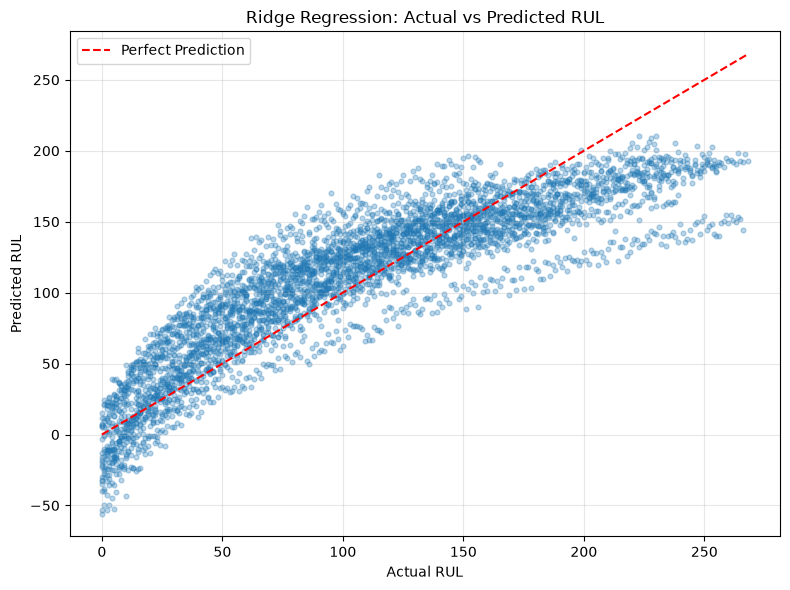

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    ridge_predictions,
    alpha=0.3,
    s=12
)

# Ideal prediction line
max_rul = max(
    y_val.max(),
    ridge_predictions.max()
)

plt.plot(
    [0, max_rul],
    [0, max_rul],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Ridge Regression: Actual vs Predicted RUL")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 10. Post-processing Negative RUL Predictions

In [17]:
# Clip negative RUL predictions to zero
ridge_predictions_clipped = np.maximum(
    ridge_predictions,
    0
)

# Calculate metrics after clipping
ridge_clipped_mae = mean_absolute_error(
    y_val,
    ridge_predictions_clipped
)

ridge_clipped_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_predictions_clipped
    )
)

# Compare original and clipped predictions
comparison = pd.DataFrame({
    "Model": [
        "Original Ridge",
        "Clipped Ridge"
    ],
    "MAE": [
        ridge_mae,
        ridge_clipped_mae
    ],
    "RMSE": [
        ridge_rmse,
        ridge_clipped_rmse
    ]
})

print(comparison.round(2))

print(
    "\nNegative predictions after clipping:",
    (ridge_predictions_clipped < 0).sum()
)

            Model    MAE   RMSE
0  Original Ridge  25.16  31.66
1   Clipped Ridge  24.50  31.27

Negative predictions after clipping: 0


In [18]:
# Create prediction analysis dataframe
error_analysis = pd.DataFrame({
    "actual_rul": y_val.to_numpy(),
    "predicted_rul": ridge_predictions_clipped
})

# Calculate absolute error
error_analysis["absolute_error"] = (
    error_analysis["actual_rul"]
    - error_analysis["predicted_rul"]
).abs()

# Group observations by actual RUL
error_analysis["rul_range"] = pd.cut(
    error_analysis["actual_rul"],
    bins=[-1, 50, 100, 150, float("inf")],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151+"
    ]
)

# Calculate average error for each group
rul_error_summary = (
    error_analysis
    .groupby("rul_range", observed=True)
    .agg(
        observations=("absolute_error", "size"),
        mae=("absolute_error", "mean")
    )
)

print(rul_error_summary.round(2))

           observations    mae
rul_range                     
0-50               1020  19.58
51-100             1000  27.08
101-150             984  18.28
151+               1066  32.55


### 10.1 Ridge Regression Error Analysis

Negative RUL predictions were clipped to zero to enforce a physically meaningful output.

**Results:**

| Model          |   MAE |  RMSE |
| -------------- | ----: | ----: |
| Original Ridge | 25.16 | 31.66 |
| Clipped Ridge  | 24.50 | 31.27 |

Clipping eliminated all 159 negative predictions and slightly reduced prediction errors.

**Error analysis by RUL range:**

* 0–50 cycles: MAE = 19.58
* 51–100 cycles: MAE = 27.08
* 101–150 cycles: MAE = 18.28
* 151+ cycles: MAE = 32.55

The highest average error occurs for observations with RUL above 150 cycles.

The scatter plot also indicates that Ridge frequently underestimates RUL for long-lived engines.

**Next steps:** Evaluate predictions at selected observation checkpoints and compare Ridge against a nonlinear regression model.


## 11. Checkpoint-Based Validation

In [19]:
# Select fixed observation checkpoints
checkpoints = [50, 100, 150]

# Select the corresponding validation observations
checkpoint_df = val_df[
    val_df["cycle"].isin(checkpoints)
].copy()

print("Checkpoint observations:", len(checkpoint_df))

print("\nEngines represented at each checkpoint:")
print(
    checkpoint_df.groupby("cycle")["engine_id"].nunique()
)

# Prepare features and actual RUL
X_checkpoint = checkpoint_df[feature_columns]

y_checkpoint = checkpoint_df["rul"]

# Predict using our already-trained Ridge model
checkpoint_predictions = np.maximum(
    ridge_model.predict(X_checkpoint),
    0
)

# Calculate errors
checkpoint_mae = mean_absolute_error(
    y_checkpoint,
    checkpoint_predictions
)

checkpoint_rmse = np.sqrt(
    mean_squared_error(
        y_checkpoint,
        checkpoint_predictions
    )
)

print("\nCheckpoint-based Ridge results:")
print("MAE:", round(checkpoint_mae, 2))
print("RMSE:", round(checkpoint_rmse, 2))

Checkpoint observations: 59

Engines represented at each checkpoint:
cycle
50     20
100    20
150    19
Name: engine_id, dtype: int64

Checkpoint-based Ridge results:
MAE: 25.02
RMSE: 29.9


In [20]:
# Store checkpoint predictions
checkpoint_analysis = checkpoint_df[
    ["engine_id", "cycle", "rul"]
].copy()

checkpoint_analysis["predicted_rul"] = checkpoint_predictions

checkpoint_analysis["absolute_error"] = (
    checkpoint_analysis["rul"]
    - checkpoint_analysis["predicted_rul"]
).abs()

# Calculate MAE for each checkpoint
checkpoint_summary = (
    checkpoint_analysis
    .groupby("cycle")
    .agg(
        observations=("absolute_error", "size"),
        mae=("absolute_error", "mean")
    )
)

print(checkpoint_summary.round(2))

       observations    mae
cycle                     
50               20  27.59
100              20  26.20
150              19  21.09


### 11.1 Checkpoint-Based Validation Results

The Ridge Regression model was evaluated at operating cycles 50, 100, and 150.

A total of 59 observations were selected from 20 validation engines.

**Results:**

| Checkpoint | Observations |   MAE |
| ---------- | -----------: | ----: |
| Cycle 50   |           20 | 27.59 |
| Cycle 100  |           20 | 26.20 |
| Cycle 150  |           19 | 21.09 |

Overall checkpoint MAE: 25.02 cycles.

Overall checkpoint RMSE: 29.90 cycles.

**Observations:**

* Ridge Regression produced lower average errors at cycle 150 than at cycles 50 and 100.
* One engine did not reach cycle 150, resulting in 19 observations at that checkpoint.
* Checkpoint evaluation measures performance at selected operating ages rather than across all available cycles.

**Limitations:**

These results are based on 20 validation engines. Fixed checkpoints do not fully replicate the NASA test-set evaluation protocol.

The checkpoint results will serve as an additional reference when comparing Ridge Regression with LightGBM.


## 12. LightGBM Model Development

In [21]:
from lightgbm import LGBMRegressor

# Initialize LightGBM
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

# Train the model
lgbm_model.fit(X_train, y_train)

# Predict on validation engines
lgbm_predictions = lgbm_model.predict(X_val)

# Ensure RUL predictions are non-negative
lgbm_predictions_clipped = np.maximum(
    lgbm_predictions,
    0
)

print("LightGBM training completed!")

LightGBM training completed!


In [22]:
# Calculate validation metrics

lgbm_mae = mean_absolute_error(
    y_val,
    lgbm_predictions_clipped
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lgbm_predictions_clipped
    )
)

print("LightGBM Results")
print("MAE:", round(lgbm_mae, 2))
print("RMSE:", round(lgbm_rmse, 2))

# Compare with Ridge
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Ridge Regression",
        "LightGBM"
    ],
    "MAE": [
        dummy_mae,
        ridge_clipped_mae,
        lgbm_mae
    ],
    "RMSE": [
        dummy_rmse,
        ridge_clipped_rmse,
        lgbm_rmse
    ]
})

print("\nModel Comparison:")
print(model_comparison.round(2))

LightGBM Results
MAE: 23.32
RMSE: 30.64

Model Comparison:
              Model    MAE   RMSE
0   Dummy Regressor  55.36  65.72
1  Ridge Regression  24.50  31.27
2          LightGBM  23.32  30.64


In [23]:
# Predict at the same checkpoints
lgbm_checkpoint_predictions = np.maximum(
    lgbm_model.predict(X_checkpoint),
    0
)

# Calculate checkpoint metrics
lgbm_checkpoint_mae = mean_absolute_error(
    y_checkpoint,
    lgbm_checkpoint_predictions
)

lgbm_checkpoint_rmse = np.sqrt(
    mean_squared_error(
        y_checkpoint,
        lgbm_checkpoint_predictions
    )
)

# Compare Ridge and LightGBM
checkpoint_comparison = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "LightGBM"
    ],
    "MAE": [
        checkpoint_mae,
        lgbm_checkpoint_mae
    ],
    "RMSE": [
        checkpoint_rmse,
        lgbm_checkpoint_rmse
    ]
})

print(checkpoint_comparison.round(2))

              Model    MAE   RMSE
0  Ridge Regression  25.02  29.90
1          LightGBM  25.06  31.85


### 12.1 Model Comparison: Ridge vs LightGBM

Three models were evaluated on the same 20 validation engines.

**All-row validation results:**

| Model            |   MAE |  RMSE |
| ---------------- | ----: | ----: |
| Dummy Regressor  | 55.36 | 65.72 |
| Ridge Regression | 24.50 | 31.27 |
| LightGBM         | 23.32 | 30.64 |

LightGBM achieved lower overall MAE and RMSE than Ridge Regression.

**Checkpoint-based results:**

| Model            |   MAE |  RMSE |
| ---------------- | ----: | ----: |
| Ridge Regression | 25.02 | 29.90 |
| LightGBM         | 25.06 | 31.85 |

Ridge Regression achieved slightly lower checkpoint errors. The MAE difference was negligible.

**Conclusion:**

LightGBM demonstrates a modest improvement in all-row prediction performance, but this improvement does not consistently extend to the checkpoint evaluation.

Additional analysis is required before selecting the final model.

The separate NASA test dataset remains untouched.


## 13. Engine-wise Model Evaluation

In [24]:
# Create an engine-wise evaluation dataframe

engine_analysis = pd.DataFrame({
    "engine_id": val_df["engine_id"].values,
    "actual_rul": y_val.values,
    "ridge_prediction": ridge_predictions_clipped,
    "lgbm_prediction": lgbm_predictions_clipped
})

# Calculate absolute errors
engine_analysis["ridge_error"] = (
    engine_analysis["actual_rul"]
    - engine_analysis["ridge_prediction"]
).abs()

engine_analysis["lgbm_error"] = (
    engine_analysis["actual_rul"]
    - engine_analysis["lgbm_prediction"]
).abs()

# Calculate MAE separately for each engine
engine_summary = (
    engine_analysis
    .groupby("engine_id")
    .agg(
        observations=("actual_rul", "size"),
        ridge_mae=("ridge_error", "mean"),
        lgbm_mae=("lgbm_error", "mean")
    )
)

# Compare the errors
engine_summary["mae_difference"] = (
    engine_summary["ridge_mae"]
    - engine_summary["lgbm_mae"]
)

print(engine_summary.round(2))

           observations  ridge_mae  lgbm_mae  mae_difference
engine_id                                                   
1                   192      27.26     24.97            2.30
5                   269      22.55     26.32           -3.77
11                  240      16.41     12.76            3.66
13                  163      25.60     23.09            2.51
19                  158      25.02     23.23            1.80
23                  168      24.30     23.66            0.64
31                  234      17.24     21.03           -3.78
32                  191      13.42      7.05            6.37
34                  195      15.75      6.71            9.04
40                  188      13.05      8.89            4.16
45                  158      51.76     42.71            9.05
46                  256      17.57     25.76           -8.18
54                  257      18.20     22.92           -4.73
71                  208      15.21      7.37            7.83
74                  166 

In [25]:
# Count engines where each model has lower MAE

lgbm_better = (
    engine_summary["lgbm_mae"]
    < engine_summary["ridge_mae"]
).sum()

ridge_better = (
    engine_summary["ridge_mae"]
    < engine_summary["lgbm_mae"]
).sum()

print("Engines with lower LightGBM MAE:", lgbm_better)

print("Engines with lower Ridge MAE:", ridge_better)

# Check Engine 84 specifically
if 84 in engine_summary.index:
    print("\nEngine 84 comparison:")
    print(engine_summary.loc[84].round(2))

# Display largest MAE for each model
print("\nLargest engine-level MAE:")

print("Ridge:", round(engine_summary["ridge_mae"].max(), 2))

print("LightGBM:", round(engine_summary["lgbm_mae"].max(), 2))

Engines with lower LightGBM MAE: 14
Engines with lower Ridge MAE: 6

Engine 84 comparison:
observations      267.00
ridge_mae          50.25
lgbm_mae           46.91
mae_difference      3.34
Name: 84, dtype: float64

Largest engine-level MAE:
Ridge: 51.76
LightGBM: 46.91


## 14. Equal-Weighted Engine Evaluation

In [26]:
# Calculate mean MAE across engines

ridge_engine_mae = engine_summary["ridge_mae"].mean()

lgbm_engine_mae = engine_summary["lgbm_mae"].mean()

# Create comparison table
engine_weighted_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "LightGBM"
    ],
    "Mean Engine MAE": [
        ridge_engine_mae,
        lgbm_engine_mae
    ]
})

print(engine_weighted_results.round(2))

              Model  Mean Engine MAE
0  Ridge Regression            25.19
1          LightGBM            23.67


In [27]:
# Define possible observation checkpoints
possible_checkpoints = [50, 100, 125]

# Fixed random seed for reproducibility
rng = np.random.default_rng(42)

# Obtain validation engine IDs
engine_ids = np.sort(
    val_df["engine_id"].unique()
)

# Select one checkpoint for each engine
selected_cycles = rng.choice(
    possible_checkpoints,
    size=len(engine_ids)
)

# Create engine-to-checkpoint mapping
checkpoint_map = dict(
    zip(engine_ids, selected_cycles)
)

# Select one observation per engine
snapshot_df = val_df[
    val_df["cycle"].eq(
        val_df["engine_id"].map(checkpoint_map)
    )
].copy()

# Verify observations
print("Total observations:", len(snapshot_df))

print(
    "Unique engines:",
    snapshot_df["engine_id"].nunique()
)

print(
    snapshot_df[
        ["engine_id", "cycle", "rul"]
    ].head(10)
)

assert len(snapshot_df) == len(engine_ids)
assert snapshot_df["engine_id"].is_unique

Total observations: 20
Unique engines: 20
      engine_id  cycle  rul
49            1     50  142
971           5    125  144
2235         11    100  140
2645         13    100   63
3875         19    100   58
4689         23    125   43
6036         31     50  184
6345         32    125   66
6661         34     50  145
7687         40     50  138


In [28]:
# Prepare input features and target
X_snapshot = snapshot_df[feature_columns]

y_snapshot = snapshot_df["rul"]

# Ridge predictions
ridge_snapshot_pred = np.maximum(
    ridge_model.predict(X_snapshot),
    0
)

# LightGBM predictions
lgbm_snapshot_pred = np.maximum(
    lgbm_model.predict(X_snapshot),
    0
)

# Compare both models
snapshot_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "LightGBM"
    ],
    "MAE": [
        mean_absolute_error(
            y_snapshot,
            ridge_snapshot_pred
        ),
        mean_absolute_error(
            y_snapshot,
            lgbm_snapshot_pred
        )
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(
            y_snapshot,
            ridge_snapshot_pred
        )),
        np.sqrt(mean_squared_error(
            y_snapshot,
            lgbm_snapshot_pred
        ))
    ]
})

print(snapshot_results.round(2))

              Model    MAE   RMSE
0  Ridge Regression  24.62  30.19
1          LightGBM  15.54  20.00


## 15. Group-Based Cross-Validation


In [29]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

import numpy as np
import pandas as pd

# Five-fold cross-validation
gkf = GroupKFold(n_splits=5)

cv_results = []

# Split entire engine trajectories
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df, groups=df["engine_id"]),
    start=1
):

    fold_train = df.iloc[train_idx].copy()
    fold_val = df.iloc[val_idx].copy()

    # Identify features using fold training data only
    candidates = [
        c for c in df.columns
        if c not in ["engine_id", "rul"]
    ]

    features = [
        c for c in candidates
        if fold_train[c].nunique() > 1
    ]

    X_fold_train = fold_train[features]
    y_fold_train = fold_train["rul"]

    # Evaluate one observation per validation engine
    snapshot = fold_val[
        fold_val["cycle"] == 100
    ].copy()

    assert (
        snapshot["engine_id"].nunique()
        == fold_val["engine_id"].nunique()
    )

    X_fold_val = snapshot[features]
    y_fold_val = snapshot["rul"]

    # Fresh models for every fold
    models = {
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),

        "LightGBM": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=15,
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        )
    }

    # Train and evaluate both models
    for name, model in models.items():

        model.fit(X_fold_train, y_fold_train)

        predictions = np.maximum(
            model.predict(X_fold_val),
            0
        )

        mae = mean_absolute_error(
            y_fold_val, predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val, predictions
            )
        )

        cv_results.append({
            "Fold": fold,
            "Model": name,
            "MAE": mae,
            "RMSE": rmse
        })

# Display results
cv_df = pd.DataFrame(cv_results)

print(cv_df.round(2))

   Fold     Model    MAE   RMSE
0     1     Ridge  32.44  44.38
1     1  LightGBM  33.27  43.93
2     2     Ridge  35.18  43.10
3     2  LightGBM  28.59  37.82
4     3     Ridge  42.51  48.87
5     3  LightGBM  37.00  45.78
6     4     Ridge  31.86  37.89
7     4  LightGBM  29.89  39.67
8     5     Ridge  36.65  41.16
9     5  LightGBM  32.53  40.33


In [30]:
# Calculate mean and standard deviation across folds

cv_summary = (
    cv_df
    .groupby("Model")
    .agg(
        Mean_MAE=("MAE", "mean"),
        Std_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        Std_RMSE=("RMSE", "std")
    )
)

print(cv_summary.round(2))

          Mean_MAE  Std_MAE  Mean_RMSE  Std_RMSE
Model                                           
LightGBM     32.26     3.26      41.51      3.26
Ridge        35.73     4.27      43.08      4.06


### 15.1 Five-Fold Cross-Validation Results

Five-fold GroupKFold cross-validation was performed using engine IDs as groups.

Each fold contained complete training and validation engine trajectories, preventing overlap between the two groups.

Predictions were evaluated at operating cycle 100, with one observation per validation engine.

| Model            | Mean MAE | Std MAE | Mean RMSE | Std RMSE |
| ---------------- | -------: | ------: | --------: | -------: |
| Ridge Regression |    35.73 |    4.27 |     43.08 |     4.06 |
| LightGBM         |    32.26 |    3.26 |     41.51 |     3.26 |

**Observations:**

* LightGBM achieved lower mean MAE and RMSE across the five folds.
* LightGBM exhibited less fold-to-fold variation in MAE.
* The differences are specific to the cycle-100 evaluation protocol and should not be generalized to all possible prediction points.

**Model development decision:**

LightGBM will be used as the provisional model for the initial held-out test evaluation.

The existing model configuration will be retained without further hyperparameter tuning.

The final model will be retrained on all 100 training engines and evaluated once on NASA's separate test dataset.


## 16. NASA Test Dataset Preparation

In [31]:
# Load NASA test data

TEST_PATH = (
    PROJECT_ROOT / "data" / "raw" / "test_FD001.txt"
)

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Test dataset shape:", test_df.shape)

print(
    "Number of test engines:",
    test_df["engine_id"].nunique()
)

print("\nFirst five rows:")
print(test_df.head())

Test dataset shape: (13096, 26)
Number of test engines: 100

First five rows:
   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1     0.0023     0.0003      100.0    518.67    643.02   
1          1      2    -0.0027    -0.0003      100.0    518.67    641.71   
2          1      3     0.0003     0.0001      100.0    518.67    642.46   
3          1      4     0.0042     0.0000      100.0    518.67    642.44   
4          1      5     0.0014     0.0000      100.0    518.67    642.51   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1585.29   1398.21     14.62  ...     521.72    2388.03    8125.55   
1   1588.45   1395.42     14.62  ...     522.16    2388.06    8139.62   
2   1586.94   1401.34     14.62  ...     521.97    2388.03    8130.10   
3   1584.12   1406.42     14.62  ...     521.38    2388.05    8132.90   
4   1587.19   1401.92     14.62  ...     522.15    2388.03    8129.54   

   sensor_15  sensor_16  s

In [32]:
# Load NASA ground-truth RUL labels

RUL_PATH = (
    PROJECT_ROOT / "data" / "raw" / "RUL_FD001.txt"
)

test_rul = pd.read_csv(
    RUL_PATH,
    sep=r"\s+",
    header=None,
    names=["actual_rul"]
)

print("RUL file shape:", test_rul.shape)

print(
    "Number of RUL labels:",
    len(test_rul)
)

RUL file shape: (100, 1)
Number of RUL labels: 100


In [33]:
# Sort observations by engine and operating cycle
test_sorted = test_df.sort_values(
    ["engine_id", "cycle"]
)

# Select the last available observation per engine
test_last = (
    test_sorted
    .groupby("engine_id")
    .tail(1)
    .sort_values("engine_id")
    .reset_index(drop=True)
)

print("Final test observations:", len(test_last))

print("\nUnique engines:", test_last["engine_id"].nunique())

print("\nFirst five final observations:")
print(test_last[["engine_id", "cycle"]].head())

# Verify that labels and engines align
assert len(test_last) == len(test_rul)

assert np.array_equal(
    test_last["engine_id"].to_numpy(),
    np.arange(1, len(test_rul) + 1)
)

print("\nTest data verification successful!")

Final test observations: 100

Unique engines: 100

First five final observations:
   engine_id  cycle
0          1     31
1          2     49
2          3    126
3          4    106
4          5     98

Test data verification successful!


## 17. Final Model Training and Test Evaluation

In [34]:
from lightgbm import LGBMRegressor

# Step 1: Select candidate features
candidate_features = [
    col for col in df.columns
    if col not in ["engine_id", "rul"]
]

# Step 2: Identify constant features from training data
constant_features = [
    col for col in candidate_features
    if df[col].nunique() == 1
]

# Step 3: Select final features
final_features = [
    col for col in candidate_features
    if col not in constant_features
]

print("Final features:", final_features)
print("Number of features:", len(final_features))

# Step 4: Prepare the complete training dataset
X_final_train = df[final_features]
y_final_train = df["rul"]

print("\nTraining data shape:", X_final_train.shape)

# Step 5: Initialize the frozen model configuration
final_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

# Step 6: Train on all 100 training engines
final_model.fit(X_final_train, y_final_train)

print("\nFinal LightGBM model trained successfully!")

Final features: ['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of features: 18

Training data shape: (20631, 18)

Final LightGBM model trained successfully!


In [35]:
# Prepare test features

X_final_test = test_last[final_features]

# NASA ground-truth RUL labels
y_final_test = test_rul["actual_rul"]

# Verify dimensions
print("Test feature shape:", X_final_test.shape)
print("Test target shape:", y_final_test.shape)

# Confirm feature consistency
assert list(X_final_test.columns) == list(X_final_train.columns)

assert len(X_final_test) == len(y_final_test) == 100

print("\nFinal test inputs verified!")

Test feature shape: (100, 18)
Test target shape: (100,)

Final test inputs verified!


In [36]:
# Generate predictions on held-out test engines
test_predictions = final_model.predict(X_final_test)

# Clip negative predictions
test_predictions_clipped = np.maximum(
    test_predictions,
    0
)

# Prepare prediction results
test_results = pd.DataFrame({
    "engine_id": test_last["engine_id"].to_numpy(),
    "observed_cycle": test_last["cycle"].to_numpy(),
    "actual_rul": y_final_test.to_numpy(),
    "predicted_rul": test_predictions_clipped
})

# Calculate absolute errors
test_results["absolute_error"] = (
    test_results["actual_rul"]
    - test_results["predicted_rul"]
).abs()

print("First 10 test predictions:")

print(test_results.head(10).round(2))

First 10 test predictions:
   engine_id  observed_cycle  actual_rul  predicted_rul  absolute_error
0          1              31         112         176.80           64.80
1          2              49          98         150.02           52.02
2          3             126          69          53.87           15.13
3          4             106          82          82.37            0.37
4          5              98          91         101.34           10.34
5          6             105          93         101.17            8.17
6          7             160          91         103.46           12.46
7          8             166          95          70.81           24.19
8          9              55         111         137.59           26.59
9         10             192          96         107.21           11.21


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate test metrics
test_mae = mean_absolute_error(
    y_final_test,
    test_predictions_clipped
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        test_predictions_clipped
    )
)

print("NASA FD001 - Held-Out Test Results")
print("--------------------------------")

print("Test engines:", len(y_final_test))

print("MAE:", round(test_mae, 2))
print("RMSE:", round(test_rmse, 2))

print(
    "Negative predictions:",
    (test_predictions_clipped < 0).sum()
)

NASA FD001 - Held-Out Test Results
--------------------------------
Test engines: 100
MAE: 19.04
RMSE: 26.33
Negative predictions: 0


## 17.1 Final Model Evaluation

The final LightGBM model was trained using all 100 FD001 training engines and evaluated on NASA's separate test dataset.

The model uses 18 input features comprising the operating cycle, two operational settings, and 15 variable sensor measurements.

### Held-Out Test Results

| Metric                              |       Result |
| ----------------------------------- | -----------: |
| Test engines                        |          100 |
| MAE                                 | 19.04 cycles |
| RMSE                                | 26.33 cycles |
| Negative predictions after clipping |            0 |

### Observations

The model achieves an average absolute prediction error of 19.04 operating cycles.

However, some engines exhibit substantially larger errors. For example, Engine 1 has an actual RUL of 112 cycles but receives a prediction of 176.80 cycles.

This illustrates that aggregate metrics can hide significant individual prediction errors.

### Limitations

* The dataset contains simulated aircraft engine degradation data.
* The model uses current-cycle measurements rather than historical sensor sequences.
* Large individual prediction errors remain.
* The system has not been validated for real-world maintenance decisions.

The test results represent the evaluation of the frozen Version 1 model. Subsequent changes will require a clearly documented evaluation procedure.


## 18. Saved Model Reproducibility

In [38]:
import joblib
import numpy as np

# Load saved model artifact
MODEL_PATH = PROJECT_ROOT / "models" / "rul_model_v1.joblib"

artifact = joblib.load(MODEL_PATH)

saved_model = artifact["model"]
saved_features = artifact["feature_names"]

# Prepare the same test inputs
X_test_saved = test_last[saved_features]

# Generate predictions using saved model
saved_predictions = np.maximum(
    saved_model.predict(X_test_saved),
    0
)

# Compare against original notebook predictions
print(
    "Predictions match:",
    np.allclose(
        saved_predictions,
        test_predictions_clipped,
        rtol=1e-6,
        atol=1e-6
    )
)

# Calculate maximum prediction difference
max_difference = np.max(
    np.abs(
        saved_predictions - test_predictions_clipped
    )
)

print("Maximum difference:", max_difference)

# Verify prediction count
print("Total predictions:", len(saved_predictions))

Predictions match: True
Maximum difference: 0.0
Total predictions: 100


In [39]:
import json
import urllib.request
import numpy as np

# Prepare real engine data
engine = test_last.iloc[0]

payload = {
    feature: (
        int(engine[feature])
        if feature == "cycle"
        else float(engine[feature])
    )
    for feature in final_features
}

# Create HTTP request
request = urllib.request.Request(
    "http://127.0.0.1:8000/predict",
    data=json.dumps(payload).encode("utf-8"),
    headers={"Content-Type": "application/json"},
    method="POST"
)

# Send request to Docker
with urllib.request.urlopen(request) as response:
    result = json.load(response)

print("Docker API response:", result)

# Compare against saved model prediction
expected = float(saved_predictions[0])

print("Expected RUL:", round(expected, 2))
print("Docker RUL:", round(result["predicted_rul"], 2))

assert np.isclose(
    result["predicted_rul"],
    expected,
    rtol=1e-6,
    atol=1e-4
)

print("Docker inference verification passed!")

Docker API response: {'predicted_rul': 176.80037906247583, 'unit': 'cycles'}
Expected RUL: 176.8
Docker RUL: 176.8
Docker inference verification passed!


# 19. Conclusion and Key Takeaways

## Project Summary

This project developed a machine learning model to predict the Remaining Useful Life (RUL) of aircraft engines using NASA's simulated C-MAPSS FD001 dataset.

The analysis covered data exploration, sensor behavior, feature selection, engine-level validation, baseline modeling, LightGBM training, held-out test evaluation, and saved-model reproducibility.

## Final Model Performance

The final LightGBM model was evaluated on 100 engines from the NASA FD001 test dataset.

| Metric | Result |
|---|---:|
| Mean Absolute Error (MAE) | 19.04 cycles |
| Root Mean Squared Error (RMSE) | 26.33 cycles |

One prediction was generated per test engine using its final available sensor observation.

## Key Learnings

- Engine-level validation prevents observations from the same engine appearing in both training and validation sets.
- Several sensors and operating settings are constant in FD001 and can be excluded from the model.
- Model performance should be evaluated using both overall error metrics and individual engine predictions.
- A saved model should be checked against the original model to verify prediction consistency.

## Limitations

- The dataset contains simulated engine degradation rather than real aircraft maintenance records.
- The model uses individual observations without explicitly modeling complete sensor histories.
- Some engines have substantially larger prediction errors than the overall MAE.
- The held-out test set has already been evaluated for Version 1 and should not be reused for future model selection.
- The system is a research prototype and is not validated for safety-critical maintenance decisions.

## Future Work

Potential extensions include historical sensor features, additional C-MAPSS subsets, improved model monitoring, and deployment enhancements.